In [ ]:
import numpy as np
import pandas as pd
import re
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url = 'https://traveltriangle.com/tour-packages/india'
response = requests.get(url)
response

<Response [200]>

In [ ]:
pagecontent = response.text
#pagecontent

In [ ]:
soup = BeautifulSoup(pagecontent)
#soup

In [ ]:
name = soup.find_all("span",attrs = {"class":"fw9 m0 f16 pfc3"})
name

[<span class="fw9 m0 f16 pfc3">Most Reasonable Goa Honeymoon Tour Packages</span>,
 <span class="fw9 m0 f16 pfc3">Fantastic Andaman Honeymoon Package</span>,
 <span class="fw9 m0 f16 pfc3">Romantic Mussoorie Tour Package From Delhi</span>,
 <span class="fw9 m0 f16 pfc3">Coorg Package For 2 Nights And 3 Days</span>,
 <span class="fw9 m0 f16 pfc3">Best 4N 5D Andaman Sightseeing Tour Package For A Refreshing Getaway</span>,
 <span class="fw9 m0 f16 pfc3">Mesmerising Manali Trip Package From Chandigarh</span>,
 <span class="fw9 m0 f16 pfc3">Hills &amp; Houseboat: Munnar and Alleppey Honeymoon Package </span>,
 <span class="fw9 m0 f16 pfc3">Top Family Holiday Packages in Goa for an Ideal Family Vacation</span>,
 <span class="fw9 m0 f16 pfc3">Most Affordable 1 Night 2 Days Uttarakhand Tour Packages From Delhi</span>,
 <span class="fw9 m0 f16 pfc3">Top 4 Nights 5 Days Best-Selling Sikkim Gangtok Darjeeling Tour Package</span>,
 <span class="fw9 m0 f16 pfc3">Best 5 Night 6 Day Leh Ladakh Tour 

In [ ]:
names = []
for x in soup.find_all("span",attrs = {"class":"fw9 m0 f16 pfc3"}):
    names.append(x.text.strip() if x else np.nan)
for name in names:
    print(name)

Most Reasonable Goa Honeymoon Tour Packages
Fantastic Andaman Honeymoon Package
Romantic Mussoorie Tour Package From Delhi
Coorg Package For 2 Nights And 3 Days
Best 4N 5D Andaman Sightseeing Tour Package For A Refreshing Getaway
Mesmerising Manali Trip Package From Chandigarh
Hills & Houseboat: Munnar and Alleppey Honeymoon Package
Top Family Holiday Packages in Goa for an Ideal Family Vacation
Most Affordable 1 Night 2 Days Uttarakhand Tour Packages From Delhi
Top 4 Nights 5 Days Best-Selling Sikkim Gangtok Darjeeling Tour Package
Best 5 Night 6 Day Leh Ladakh Tour Package For A Fun Filled Vacay
Postcard-Perfect Sikkim Gangtok Lachung Honeymoon Packages
Best Selling Kerala Houseboat & Jungle Safari Tour Package
Go on an excursion to Shillong to witness the best of natural attraction
Top 5 Nights 6 Days Kerala Family Tour Packages For A Refreshing Getaway
Exciting Goa Tour Packages For A Perfect Getaway
Discover Our Beautiful 4 Nights 5 Days Andaman Family Tour Packages
4 Nights 5 Day

In [ ]:
percent = soup.find("span",attrs = {"class":"f12 fw4 pt2 pb2 pl8 pr8 radius20 pbc1 sfcw at_discount_label"})
percent

<span class="f12 fw4 pt2 pb2 pl8 pr8 radius20 pbc1 sfcw at_discount_label">13<!-- -->% Off</span>

In [ ]:
dp = []
for x in soup.find_all("span",attrs = {"class":"f12 fw4 pt2 pb2 pl8 pr8 radius20 pbc1 sfcw at_discount_label"}):
    dp.append(x.text.strip() if x else np.nan)

for percent in dp:
    print(percent)

13% Off
17% Off
13% Off
9% Off
9% Off
9% Off
10% Off
8% Off
17% Off
16% Off
22% Off
8% Off
19% Off
13% Off
18% Off
7% Off
19% Off
17% Off
15% Off
7% Off


In [ ]:
import time
import requests
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
import re

Name=[]
stay=[]
location=[]
discount=[]
price=[]
original_price=[]
rating=[]
reviews=[]
packages=[]
links=[]
pagenum=[]

headers={"User-Agent":"Mozilla/5.0"}

for i in range(1,51):

    start_page=time.time()

    URL=f"https://traveltriangle.com/tour-packages/india?page={i}"
    page=requests.get(URL,headers=headers)

    soup=BeautifulSoup(page.text,"lxml")

    cards=soup.find_all("div",attrs={"class":"col-12 p8 pt0"})

    print("Page:",i,"Cards:",len(cards))

    for x in cards:

        name_tag=x.find("p",attrs={"class":"col-md-12 pl0 fw9 m0 f16 pfc3 at_packageName"})
        stay_tag=x.find("span",attrs={"class":"iblock sfc6"})
        location_tag=x.find("ul",attrs={"class":"clearfix package-cities-list at_packagecity_list"})
        discount_tag=x.find("span",attrs={"class":"f12 fw4 pt2 pb2 pl8 pr8 radius20 pbc1 sfcw at_discount_label"})
        price_tag=x.find("p",attrs={"class":"sfc3 m0 f20 fw9 priceVal at_newprice"})
        tags_tag=x.find("ul",attrs={"class":"package-tags at_package_tags"})
        original_tag=x.find("span",attrs={"class":re.compile("at_actualPrice|tdl")})
        link_tag=x.find("a",href=True)

        card_text=x.get_text(" ",strip=True)

        rating_match=re.search(r"\b[1-5](?:\.\d)?\b",card_text)

        Name.append(name_tag.get_text(strip=True) if name_tag else np.nan)
        stay.append(stay_tag.get_text(strip=True) if stay_tag else np.nan)
        location.append(location_tag.get_text(" ",strip=True) if location_tag else np.nan)
        discount.append(discount_tag.get_text(strip=True) if discount_tag else np.nan)
        price.append(price_tag.get_text(strip=True) if price_tag else np.nan)
        original_price.append(original_tag.get_text(strip=True) if original_tag else np.nan)

        rating.append(rating_match.group() if rating_match else np.nan)

        packages.append(tags_tag.get_text(" ",strip=True) if tags_tag else np.nan)
        links.append(("https://traveltriangle.com"+link_tag["href"]) if link_tag else np.nan)
        pagenum.append(i)

    print(f"Page {i} done in {time.time()-start_page:.2f} seconds")

Page: 1 Cards: 20
Page 1 done in 0.28 seconds
Page: 2 Cards: 20
Page 2 done in 0.52 seconds
Page: 3 Cards: 20
Page 3 done in 0.71 seconds
Page: 4 Cards: 20
Page 4 done in 0.52 seconds
Page: 5 Cards: 20
Page 5 done in 0.75 seconds
Page: 6 Cards: 20
Page 6 done in 0.43 seconds
Page: 7 Cards: 20
Page 7 done in 0.45 seconds
Page: 8 Cards: 20
Page 8 done in 0.74 seconds
Page: 9 Cards: 20
Page 9 done in 0.48 seconds
Page: 10 Cards: 20
Page 10 done in 0.49 seconds
Page: 11 Cards: 20
Page 11 done in 0.43 seconds
Page: 12 Cards: 20
Page 12 done in 0.27 seconds
Page: 13 Cards: 20
Page 13 done in 0.28 seconds
Page: 14 Cards: 20
Page 14 done in 0.43 seconds
Page: 15 Cards: 20
Page 15 done in 0.27 seconds
Page: 16 Cards: 20
Page 16 done in 0.27 seconds
Page: 17 Cards: 20
Page 17 done in 0.46 seconds
Page: 18 Cards: 20
Page 18 done in 0.28 seconds
Page: 19 Cards: 20
Page 19 done in 0.35 seconds
Page: 20 Cards: 20
Page 20 done in 0.52 seconds
Page: 21 Cards: 20
Page 21 done in 0.37 seconds
Page: 22 C

In [ ]:
df_raw=pd.DataFrame({
"Name":Name,
"Stay":stay,
"Location":location,
"Discount":discount,
"Discount_Price":price,
"Original_Price":original_price,
"Rating":rating,
"Packages":packages,
"Link":links,
"Page_Number":pagenum
})

In [ ]:
df_raw.shape

(1000, 10)

In [ ]:
df_raw.to_csv("rawdata.csv",index=False)

In [ ]:
df = pd.read_csv("rawdata.csv")
df

,Name,Stay,Location,Discount,Discount_Price,Original_Price,Rating,Packages,Link,Page_Number
0,Most Reasonable Goa Honeymoon Tour Packages,5Days &4Nights,Goa (5D),13% Off,"â¹ 7,999/-â¹ 9,142/-","â¹ 9,142/-",3,Hot Pick Water Activities Romantic Cruise Adve...,https://traveltriangle.com/packages/4nights-5d...,1
1,Fantastic Andaman Honeymoon Package,5Days &4Nights,Port Blair (3D) Havelock (2D),17% Off,"â¹ 15,599/-â¹ 18,811/-","â¹ 18,811/-",3,Corbyn's Beach Cove Adventure Radhanagar Beach...,https://traveltriangle.com/packages/4nights-5d...,1
2,Romantic Mussoorie Tour Package From Delhi,3Days &2Nights,Mussoorie (3D),13% Off,"â¹ 10,500/-â¹ 12,000/-","â¹ 12,000/-",3,Sightseeing Nature Hill station Himalayas Roma...,https://traveltriangle.com/packages/romantic-2...,1
3,Coorg Package For 2 Nights And 3 Days,3Days &2Nights,Coorg (3D),9% Off,"â¹ 14,500/-â¹ 15,934/-","â¹ 15,934/-",2,Coorg sightseeing Adventure Rajaâs Seat Natu...,https://traveltriangle.com/packages/2nights-3d...,1
4,Best 4N 5D Andaman Sightseeing Tour Package Fo...,5Days &4Nights,Port Blair (4D) Havelock (1D),9% Off,"â¹ 33,200/-â¹ 36,484/-","â¹ 36,484/-",3,Cellular Jail Light & Sound Show Adventure Nat...,https://traveltriangle.com/packages/4nights-5d...,1
...,...,...,...,...,...,...,...,...,...,...
995,Exciting Goa Tour Packages For A Perfect Getaway,3Days &2Nights,Goa (3D),7% Off,"â¹ 14,500/-â¹ 15,615/-","â¹ 15,615/-",3,Beach vacation Adventure Nightlife Nature Shop...,https://traveltriangle.com/packages/2nights-3d...,50
996,Discover Our Beautiful 4 Nights 5 Days Andaman...,5Days &4Nights,Port Blair (4D) Havelock (1D),19% Off,"â¹ 18,990/-â¹ 23,574/-","â¹ 23,574/-",4,Watersports Beach Vacation Light & Sound Show ...,https://traveltriangle.com/packages/4nights-5d...,50
997,4 Nights 5 Days Sikkim Family Tour Package,5Days &4Nights,Gangtok (4D) Lachung (1D),17% Off,"â¹ 22,000/-â¹ 26,400/-","â¹ 26,400/-",4,Historical Himalayas Adventure Private Transfe...,https://traveltriangle.com/packages/4nights-5d...,50
998,Best Selling Shimla Honeymoon Tour Packages Fo...,3Days &2Nights,Shimla (3D),15% Off,"â¹ 9,000/-â¹ 10,543/-","â¹ 10,543/-",3,Adventure Hill Station Nature Scenic Landscape...,https://traveltriangle.com/packages/2nights-3d...,50


# converting datatypes

In [ ]:
df["Discount"] = df["Discount"].str.replace("% Off","", regex=False) #converting the numeric format
df["Discount"] = df["Discount"].astype(int)

In [ ]:
# cleaning the data and extracting prices after discount
df["Discount_Price"] = df["Discount_Price"].astype(str).str.extract(r"(\d[\d,]*)")[0]
df["Discount_Price"] = df["Discount_Price"].str.replace(",", "", regex=False).astype(int)

# cleaning the data and extracting original prices
df["Original_Price"] = df["Original_Price"].astype(str).str.extract(r"(\d[\d,]*)")[0]
df["Original_Price"] = df["Original_Price"].str.replace(",", "", regex=False).astype(int)

In [ ]:
df[["Discount_Price","Original_Price"]].head() # verifying those are changed or not

,Discount_Price,Original_Price
0,7999,9142
1,15599,18811
2,10500,12000
3,14500,15934
4,33200,36484


In [ ]:
df["Days"] = df["Stay"].str.extract(r"(\d+)D").astype(int) # extracting Days from stay
df["Nights"] = df["Stay"].str.extract(r"(\d+)N").astype(int) # extracting Nights from stay

In [ ]:
df = df.drop(columns='Stay') # droping the stay column because it was unwanted

In [ ]:
df.head()

,Name,Location,Discount,Discount_Price,Original_Price,Rating,Packages,Link,Page_Number,Days,Nights
0,Most Reasonable Goa Honeymoon Tour Packages,Goa (5D),13,7999,9142,3,Hot Pick Water Activities Romantic Cruise Adve...,https://traveltriangle.com/packages/4nights-5d...,1,5,4
1,Fantastic Andaman Honeymoon Package,Port Blair (3D) Havelock (2D),17,15599,18811,3,Corbyn's Beach Cove Adventure Radhanagar Beach...,https://traveltriangle.com/packages/4nights-5d...,1,5,4
2,Romantic Mussoorie Tour Package From Delhi,Mussoorie (3D),13,10500,12000,3,Sightseeing Nature Hill station Himalayas Roma...,https://traveltriangle.com/packages/romantic-2...,1,3,2
3,Coorg Package For 2 Nights And 3 Days,Coorg (3D),9,14500,15934,2,Coorg sightseeing Adventure Rajaâs Seat Natu...,https://traveltriangle.com/packages/2nights-3d...,1,3,2
4,Best 4N 5D Andaman Sightseeing Tour Package Fo...,Port Blair (4D) Havelock (1D),9,33200,36484,3,Cellular Jail Light & Sound Show Adventure Nat...,https://traveltriangle.com/packages/4nights-5d...,1,5,4


In [ ]:
df["Rating"] = df["Rating"].astype(str).str.extract(r"([1-5](?:\.\d)?)")[0]
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

In [ ]:
df["Rating"].value_counts().head(10) # verifying

,count
Rating,
3,650
4,150
5,100
1,50
2,50


In [ ]:
df["Savings"] = df["Original_Price"] - df["Discount_Price"] # creating the new column called savings to know how much amount saving to people

In [ ]:
df["Savings_Percentage"] = (df["Savings"] / df["Original_Price"]) * 100

In [ ]:
df[["Discount","Savings_Percentage"]].head()

,Discount,Savings_Percentage
0,13,12.502735
1,17,17.075116
2,13,12.500000
3,9,8.999623
4,9,9.001206


In [ ]:
df["Savings_Percentage"] = df["Savings_Percentage"].round(2)
df["Savings_Percentage"]

,Savings_Percentage
0,12.50
1,17.08
2,12.50
3,9.00
4,9.00
...,...
995,7.14
996,19.45
997,16.67
998,14.64


In [ ]:
df.columns

Index(['Name', 'Location', 'Discount', 'Discount_Price', 'Original_Price',
       'Rating', 'Packages', 'Link', 'Page_Number', 'Days', 'Nights',
       'Savings', 'Savings_Percentage'],
      dtype='object')

In [ ]:
df = df.drop(columns=['Name','Packages','Link','Page_Number']) # droping because this are unwanted data no need for analysis
df

,Location,Discount,Discount_Price,Original_Price,Rating,Days,Nights,Savings,Savings_Percentage
0,Goa (5D),13,7999,9142,3,5,4,1143,12.50
1,Port Blair (3D) Havelock (2D),17,15599,18811,3,5,4,3212,17.08
2,Mussoorie (3D),13,10500,12000,3,3,2,1500,12.50
3,Coorg (3D),9,14500,15934,2,3,2,1434,9.00
4,Port Blair (4D) Havelock (1D),9,33200,36484,3,5,4,3284,9.00
...,...,...,...,...,...,...,...,...,...
995,Goa (3D),7,14500,15615,3,3,2,1115,7.14
996,Port Blair (4D) Havelock (1D),19,18990,23574,4,5,4,4584,19.45
997,Gangtok (4D) Lachung (1D),17,22000,26400,4,5,4,4400,16.67
998,Shimla (3D),15,9000,10543,3,3,2,1543,14.64


In [ ]:
df["Location"] = df["Location"].str.replace(r"\(\d+D\)", "", regex=True).str.strip() # in location also we have unwanted data like (3D),(1D)...e.t.c
df['Location']

,Location
0,Goa
1,Port Blair Havelock
2,Mussoorie
3,Coorg
4,Port Blair Havelock
...,...
995,Goa
996,Port Blair Havelock
997,Gangtok Lachung
998,Shimla


In [ ]:
df.to_csv('cleaned.csv',index=False)

In [ ]:
df = pd.read_csv('cleaned.csv')
df

,Location,Discount,Discount_Price,Original_Price,Rating,Days,Nights,Savings,Savings_Percentage
0,Goa,13,7999,9142,3,5,4,1143,12.50
1,Port Blair Havelock,17,15599,18811,3,5,4,3212,17.08
2,Mussoorie,13,10500,12000,3,3,2,1500,12.50
3,Coorg,9,14500,15934,2,3,2,1434,9.00
4,Port Blair Havelock,9,33200,36484,3,5,4,3284,9.00
...,...,...,...,...,...,...,...,...,...
995,Goa,7,14500,15615,3,3,2,1115,7.14
996,Port Blair Havelock,19,18990,23574,4,5,4,4584,19.45
997,Gangtok Lachung,17,22000,26400,4,5,4,4400,16.67
998,Shimla,15,9000,10543,3,3,2,1543,14.64


# Outliers

In [ ]:
numeric = ["Discount","Discount_Price","Original_Price","Rating","Days","Nights","Savings","Savings_Percentage"]

for col in numeric:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3-Q1

    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR

    outliers = df[(df[col]<lower)|(df[col]>upper)]

    print(col, ":", len(outliers), "outliers")

Discount : 0 outliers
Discount_Price : 0 outliers
Original_Price : 0 outliers
Rating : 350 outliers
Days : 0 outliers
Nights : 0 outliers
Savings : 0 outliers
Savings_Percentage : 0 outliers


# Visualization of outliers

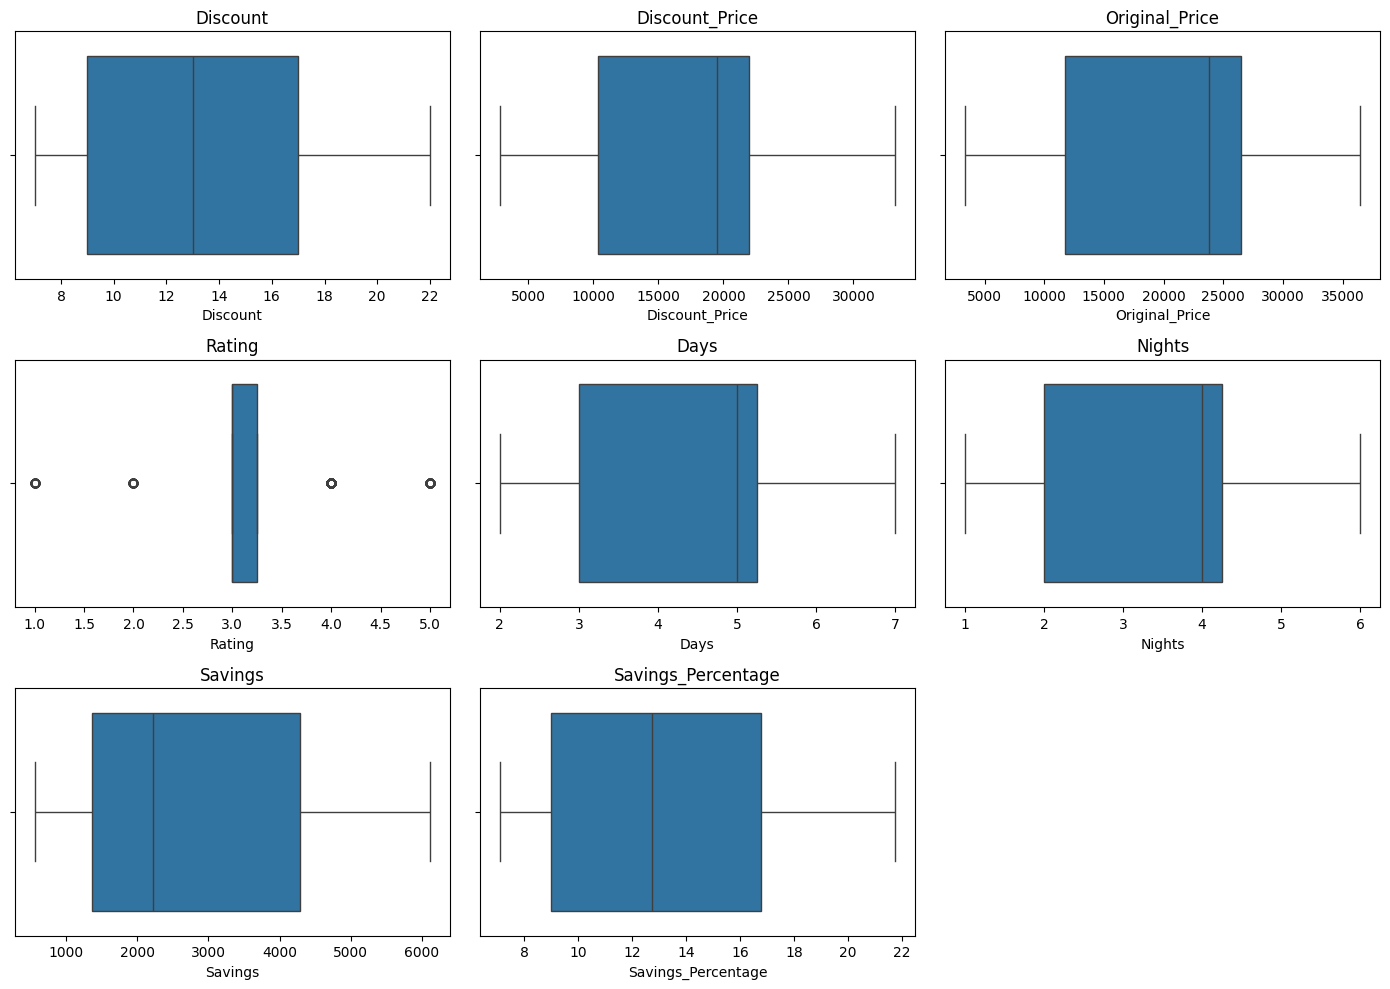

In [ ]:
numeric = ["Discount","Discount_Price","Original_Price","Rating","Days","Nights","Savings","Savings_Percentage"]
plt.figure(figsize=(14,10))
for i, col in enumerate(numeric,1):
    plt.subplot(3,3,i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Univariate


In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import plotly.express as px

# Categorical

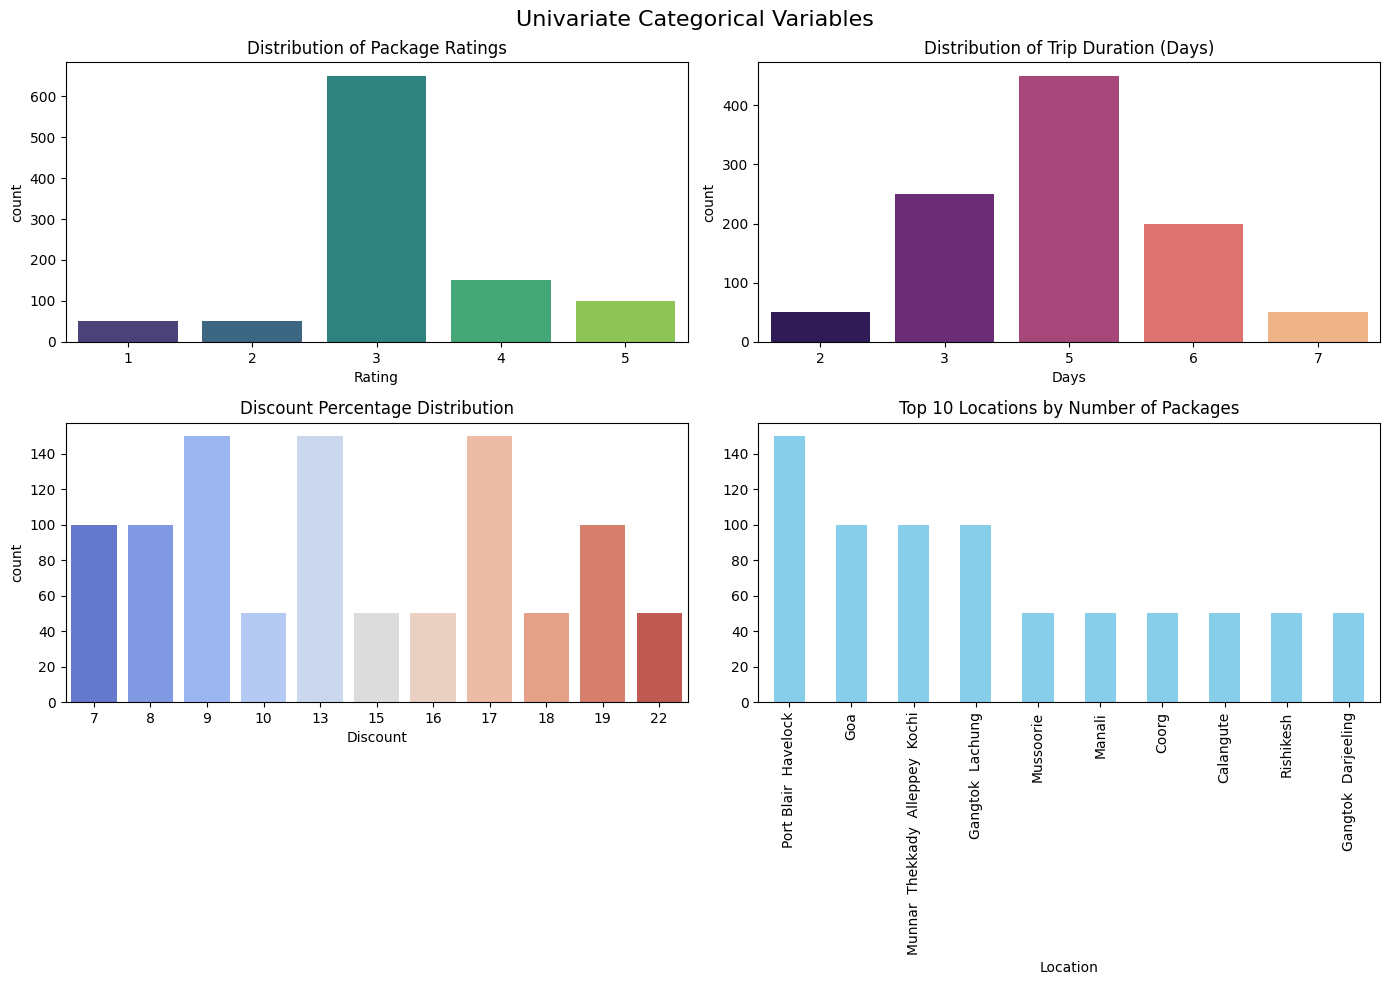

In [ ]:
# using the count & bar

plt.figure(figsize=(14,10))

# Rating Count Plot
plt.subplot(2,2,1)
sns.countplot(x="Rating", data=df, palette="viridis")
plt.title("Distribution of Package Ratings")

# Days Count Plot
plt.subplot(2,2,2)
sns.countplot(x="Days", data=df, palette="magma")
plt.title("Distribution of Trip Duration (Days)")

# Discount Bar Plot
plt.subplot(2,2,3)
sns.countplot(x="Discount", data=df, palette="coolwarm")
plt.title("Discount Percentage Distribution")

# Top Locations
plt.subplot(2,2,4)
df["Location"].value_counts().head(10).plot(kind="bar", color="skyblue")
plt.title("Top 10 Locations by Number of Packages")


plt.suptitle("Univariate Categorical Variables", fontsize=16)
plt.tight_layout()
plt.show()

# Numerical

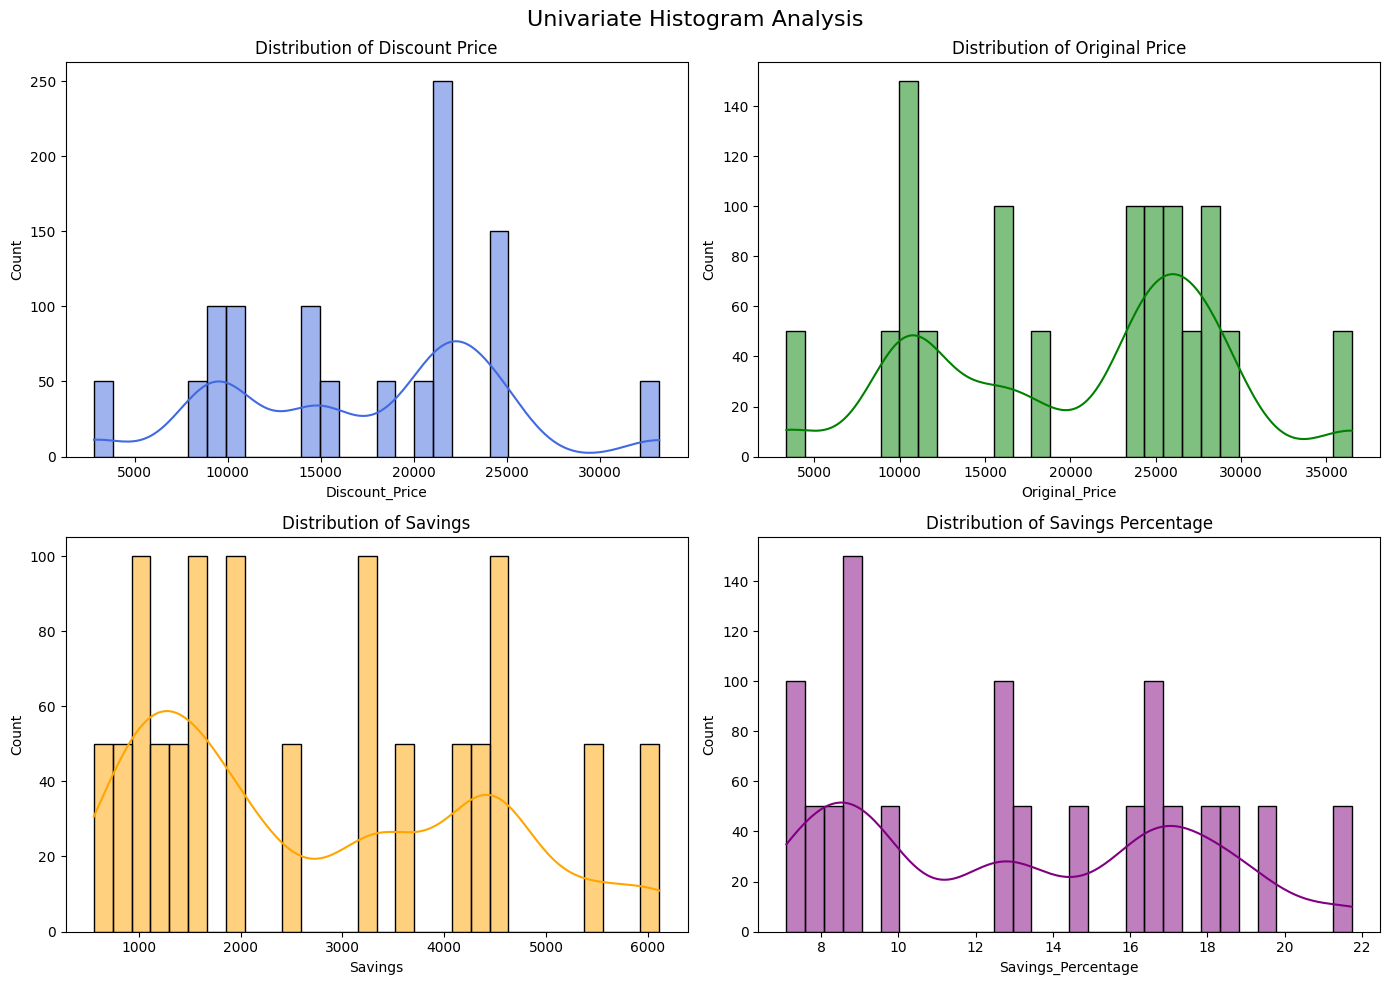

In [ ]:
# using histogram

plt.figure(figsize=(14,10))

# Discount Price
plt.subplot(2,2,1)
sns.histplot(df["Discount_Price"], bins=30, kde=True, color="royalblue")
plt.title("Distribution of Discount Price")

# Original Price
plt.subplot(2,2,2)
sns.histplot(df["Original_Price"], bins=30, kde=True, color="green")
plt.title("Distribution of Original Price")

# Savings
plt.subplot(2,2,3)
sns.histplot(df["Savings"], bins=30, kde=True, color="orange")
plt.title("Distribution of Savings")

# Savings Percentage
plt.subplot(2,2,4)
sns.histplot(df["Savings_Percentage"], bins=30, kde=True, color="purple")
plt.title("Distribution of Savings Percentage")

plt.suptitle("Univariate Histogram Analysis", fontsize=16)
plt.tight_layout()
plt.show()

# Bivariate

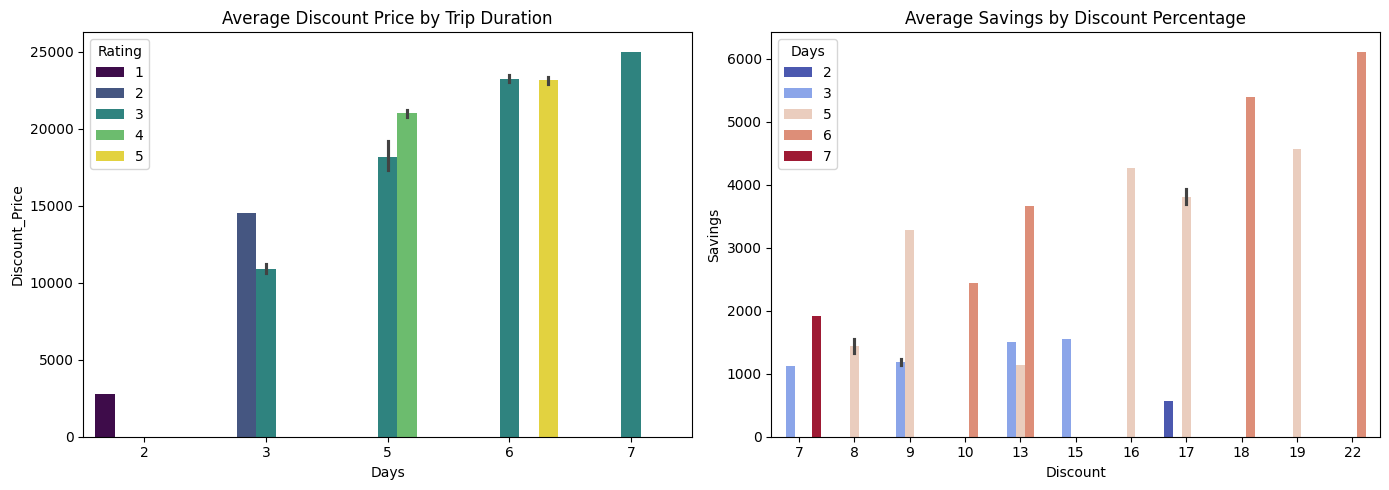

In [ ]:
plt.figure(figsize=(14,5))

# Days vs Average Discount Price
plt.subplot(1,2,1)
sns.barplot(
    x="Days",
    y="Discount_Price",
    hue="Rating",
    palette="viridis",
    data=df
)
plt.title("Average Discount Price by Trip Duration")

# Discount vs Average Savings
plt.subplot(1,2,2)
sns.barplot(
    x="Discount",
    y="Savings",
    hue="Days",
    palette="coolwarm",
    data=df
)
plt.title("Average Savings by Discount Percentage")

plt.tight_layout()
plt.show()

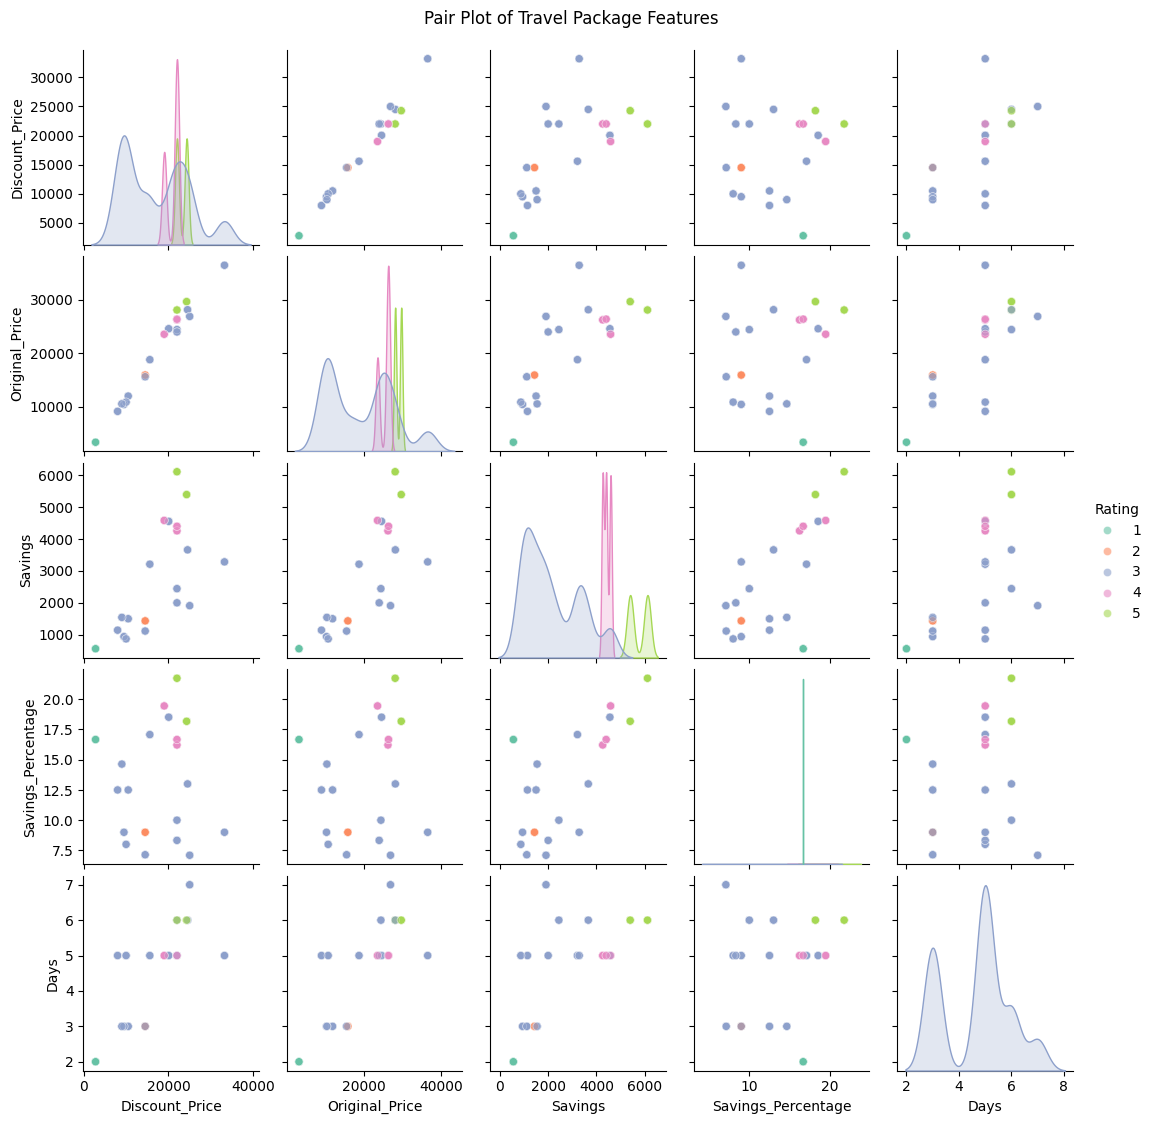

In [ ]:
# pair plot
cols = ["Discount_Price","Original_Price","Savings","Savings_Percentage","Days"]
sns.pairplot(
    df[cols + ["Rating"]],
    hue="Rating",
    diag_kind="kde",
    palette="Set2",
    plot_kws={"alpha":0.6, "s":35},
    height=2.2
)
plt.suptitle("Pair Plot of Travel Package Features (Hue = Rating)", y=1.02)
plt.show()

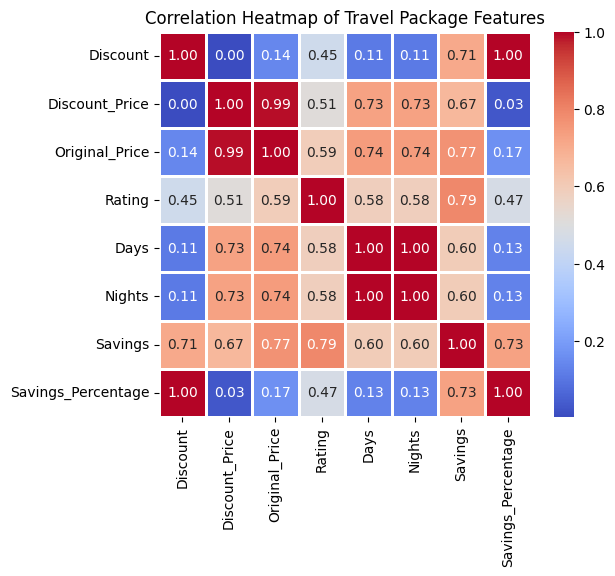

In [ ]:
# heatmap
numeric_cols = ["Discount", "Discount_Price", "Original_Price",
                "Rating", "Days", "Nights", "Savings", "Savings_Percentage"]
corr = df[numeric_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=1
)
plt.title("Correlation Heatmap of Travel Package Features")
plt.show()

# multivariate

In [ ]:
# scatter 3D
fig = px.scatter_3d(
    df,
    x="Original_Price",
    y="Discount_Price",
    z="Savings",
    color="Rating",
    size="Days",
    hover_data=["Location"],
    title="3D Multivariate Travel Package Analysis"
)
fig.show()

In [ ]:
# Donut
top_locations = df["Location"].value_counts().head(8)
fig = px.pie(
    values=top_locations.values,
    names=top_locations.index,
    title="Top Travel Locations Distribution",
    hole=0.4
)
fig.show()